In [ ]:
'''
L’algorithme des k plus proches voisins permet de prédire à quelle
famille une nouvelle entrée (une nouvelle donnée) va appartenir.
Il calcule pour cela les distances de la nouvelle entrée au jeu de
donnée, c’est-à-dire la distance entre la nouvelle donnée et toutes 
celles déjà présentes dans le jeu de données.
'''

In [55]:
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, auc, precision_recall_curve
import matplotlib.pyplot as plt

In [56]:

def lire_base_met(methode):
    X = []
    y = []
    chemin_dossier="./BDshape/"
    for fichier in sorted(os.listdir(chemin_dossier)):
        if not fichier.lower().endswith(methode.lower()):
            continue
        if not fichier.lower().startswith("s"):
            continue
        
        # Normalisation du nom : on met tout en majuscules
        fichier_upper = fichier.upper()
        
        try:
            classe = int(fichier_upper[1:3])  # Sxx
        except ValueError:
            continue  # Ignore les fichiers non conformes

        chemin_fichier = os.path.join(chemin_dossier, fichier)
        with open(chemin_fichier, "r") as f:
            contenu = f.read().strip()
            valeurs = np.fromstring(contenu, sep=" ")
            X.append(valeurs)
            y.append(classe)

    return np.array(X), np.array(y)


In [57]:

"""
    Cette fonction cherche le meilleur k pour k-NN avec 
    validation croisée.
    Trace le graphique des performences par nombre de voisins
    Retourne le k optimal.
"""
def trouver_meilleur_k(X_train, y_train):
    # Normalisation des données 
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    meilleur_k = 1
    meilleurScore = -1
    accs = []
    for k in range(1, 16):
        model = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(model, X_train_norm, y_train, cv=5)
        acc = scores.mean()
        accs.append(acc)
        plt.plot(accs)
        plt.xlabel("Nombre de voisins")
        plt.ylabel("Performances")
        plt.title("Graphe des performences par nombre de voisins")
        if acc > meilleurScore:
            meilleurScore = acc
    return meilleur_k   

In [58]:

"""
    Cette fonction entraîne le KNN avec le k fourni et retourne 
    le modèle + données normalisées.
"""
def entrainer_knn(X_train, y_train, X_test, k):
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_norm, y_train)

    return model, X_train_norm, X_test_norm


In [61]:

methode = input("Donner une méthode")
X, y = lire_base_met(methode)
print("Dimensions :", X.shape)
print(X)
print(y)

Donner une méthode GFD


Dimensions : (99, 100)
[[0.242109 0.05499  0.370846 ... 0.015527 0.004433 0.007197]
 [0.262132 0.031934 0.375073 ... 0.00163  0.004381 0.005157]
 [0.253119 0.020232 0.380838 ... 0.001592 0.003358 0.006509]
 ...
 [0.127431 0.048253 0.858815 ... 0.01181  0.011898 0.007229]
 [0.136461 0.061401 0.746905 ... 0.007192 0.028977 0.006425]
 [0.121798 0.055752 0.828352 ... 0.012856 0.004695 0.008803]]
[2 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4
 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7
 7 7 7 8 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 9]


In [62]:
# Division des données 70% entrainement et 30% test 
'''
random_state => assure une division toujours identique
stratify => garantit que toutes les classes sont représentées dans train ET test
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=0, 
    stratify=y
)

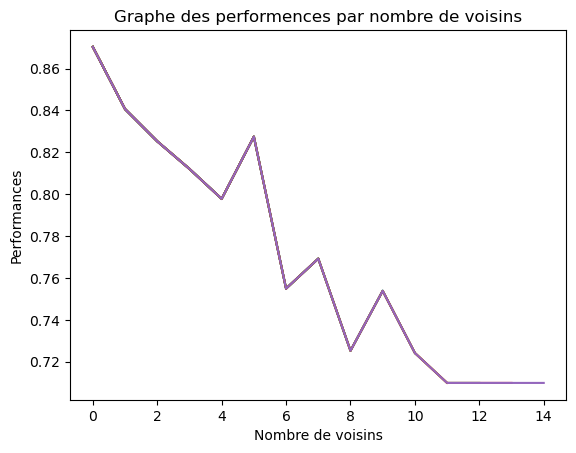

In [63]:
meilleur_k= trouver_meilleur_k(X_train, y_train)

In [64]:
model, X_train_norm, X_test_norm = entrainer_knn(X_train, y_train, X_test, meilleur_k)

In [65]:

# prédiction
y_pred = model.predict(X_test_norm)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("="*50)
# Matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("="*50)
# Rapport complet (Precision, Recall, F1 pour chaque classe)
print("Rapport de classification :")
print(classification_report(y_test, y_pred))
print("="*50)

Accuracy: 0.90
Matrice de confusion :
[[3 0 0 0 1 0 0 0 0]
 [0 3 0 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 4 0 0 0]
 [1 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 3 0]
 [0 0 0 1 0 0 0 0 2]]
Rapport de classification :
              precision    recall  f1-score   support

           1       0.75      0.75      0.75         4
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       0.80      1.00      0.89         4
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         4
           7       1.00      0.67      0.80         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



In [ ]:
''' 
3.c) Courbe précision/rappel (et AUC) avec K=10
Pour ce faire, on utiliser le modèle précédent (k‑NN avec le meilleur 𝑘).
Faire une validation croisée à 10 folds.
Calculer les précisions/rappels.
Calculer l’AUC associé.
Tracer la courbe precision/rappel.
'''

AUC: 0.906


Text(0.5, 1.0, 'Courbe précision/rappel')

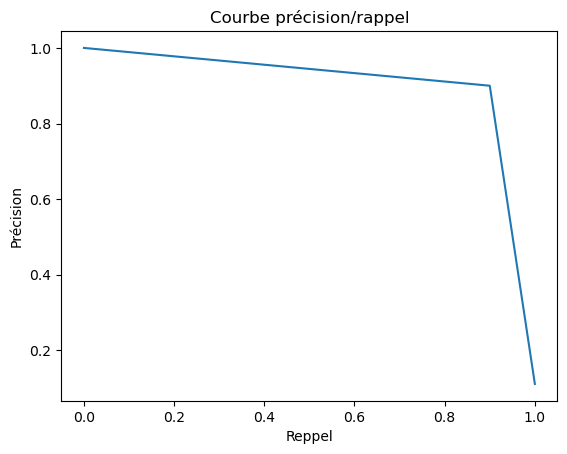

In [67]:
     #Création du modèl
sk = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
   #Entrainement du model
model = KNeighborsClassifier(n_neighbors=meilleur_k)
model.fit(X_train_norm, y_train)
   #Récupération des probas
probas = model.predict_proba(X_test_norm)
  #Transformation de y_test en vecteurs 1/0
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
  #Calcul des précision et rappels
precision, recall, thresholds = precision_recall_curve(
    y_test_bin.ravel(),    # toutes les classes mises à plat
    probas.ravel()         # toutes les probabilités mises à plat
)
  #Calcul du AUC
auc_pr = auc(recall, precision)
print(f"AUC: {auc_pr:.3f}")
  #Courbe precision/rappel
plt.plot(recall, precision)
plt.xlabel("Reppel")
plt.ylabel("Précision")
plt.title("Courbe précision/rappel")
